In [111]:
import random
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [112]:
# read in all the words
words = open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [113]:
# build the vocabulary of characters and mapping to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s, i in stoi.items()}
vocab_size = len(itos)
print(vocab_size)

27


In [114]:
# build dataset for different splits
block_size = 3       # context length: how many characters do we take to predict the next one?

def build_dataset(words):
    X, Y = [], []
    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]
    
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

random.seed(42)
random.shuffle(words)
n1 = int(0.8* len(words))
n2 = int(0.9* len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [115]:
# MLP revisited

n_embd = 10     # the dimensionality of the character embedding vectors
n_hidden = 200  # the number of neurons in the hidden layer of the MLP

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size, n_embd), generator=g)
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g)  * (5/3)/(n_embd * block_size)  # std dev
b1 = torch.randn(n_hidden, generator=g)  * 0.01
W2 = torch.randn((n_hidden, vocab_size), generator=g) * 0.01 # for fixin initial high loss error, dont set to 0, just small. -----|______ Making sure logits are closer to 0 for low initial loss
b2 = torch.randn(vocab_size, generator=g) * 0  # for fixin initial high loss error  ----------------------------------------------|

# for scaling and adding bias to batch normalization 
bngain = torch.ones((1, n_hidden))
bnbias = torch.zeros((1, n_hidden))

parameters = [C, W1, b1, W2, b2, bngain, bnbias]
print(sum(p.nelement() for p in parameters))    # number of total parameters
for p in parameters:
    p.requires_grad = True

12297


tensor(-0.0065) tensor(1.0020)
tensor(-0.0008) tensor(0.9962)


(array([3.81461382e-05, 3.81461382e-05, 0.00000000e+00, 0.00000000e+00,
        1.90730691e-05, 1.90730691e-05, 3.81461382e-05, 5.72192073e-05,
        1.33511484e-04, 2.28876829e-04, 3.24242175e-04, 6.86630488e-04,
        1.37326098e-03, 2.30784136e-03, 4.67290193e-03, 6.92352408e-03,
        1.23402757e-02, 2.12283259e-02, 3.63723428e-02, 6.07286520e-02,
        9.13600010e-02, 1.37726632e-01, 2.01468829e-01, 2.70704070e-01,
        3.43010075e-01, 4.03681507e-01, 4.25234076e-01, 4.15659395e-01,
        3.71219144e-01, 3.07324362e-01, 2.30936721e-01, 1.69120904e-01,
        1.13351250e-01, 7.39272158e-02, 4.68625308e-02, 2.67404429e-02,
        1.69750315e-02, 9.51746148e-03, 5.49304390e-03, 2.65115660e-03,
        1.56399167e-03, 1.04901880e-03, 6.29411280e-04, 2.47949898e-04,
        3.24242175e-04, 5.72192073e-05, 9.53653455e-05, 1.90730691e-05,
        7.62922764e-05, 5.72192073e-05]),
 array([-7.01081419, -6.74866446, -6.48651472, -6.22436499, -5.96221525,
        -5.70006552, 

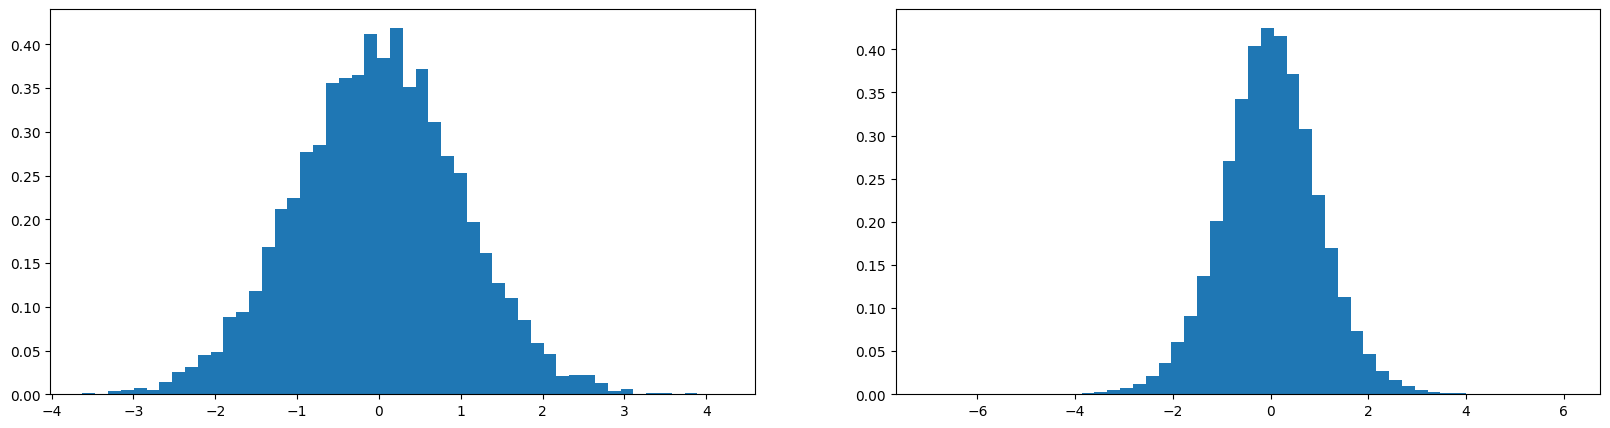

In [95]:
x = torch.randn(1000, 10)     # 1000 example, 10 dimensional
w = torch.randn(10, 200) / 10 ** 0.5     # 10 inputs, 200 neurons in hidden layer / square root (fanon)
y = x @ w
print(x.mean(), x.std())
print(y.mean(), y.std())
plt.figure(figsize=(20, 5))
plt.subplot(121)
plt.hist(x.view(-1).tolist(), 50, density=True);
plt.subplot(122)
plt.hist(y.view(-1).tolist(), 50, density=True)

In [ ]:
# batch normalization

In [116]:
hpreact.shape

torch.Size([32, 200])

In [117]:
hpreact.mean(0, keepdim=True).shape

torch.Size([1, 200])

In [118]:
hpreact.std(0, keepdim=True).shape

torch.Size([1, 200])

In [ ]:
# customary to append batch normalzation to linear layer or convolutional layers to control the scale of the activations
# function of not only one example, but other examples are also coupled together. causing h to jitter, introducing some entropy. (regularizing effect)

In [119]:
# optimization

max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):

    # minibatch contruct
    index = torch.randint(0, Xtr.shape[0], (batch_size, ), generator=g) # generating a tuple of numbers between 0 and X.shape[0]
    Xb, Yb = Xtr[index], Ytr[index]  # batch X, Y

    # forward pass
    emb = C[Xtr[index]] # embed the characters into vectors
    embcat = emb.view(emb.shape[0], -1) # concatenate the vectors
    hpreact = embcat @ W1 + b1          # hidden layer pre-activation
    hpreact = bngain * (hpreact - hpreact.mean(0, keepdim=True)) / hpreact.std(0, keepdim=True) + bnbias  # we need them roughly gaussian, but only at initialization
    h = torch.tanh(hpreact)  # hidden layer
    logits = h @ W2 + b2     # output layer
    loss = F.cross_entropy(logits, Yb)  # loss function

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = 0.1 if i < 100000 else 0.01   # step learning decay
    for p in parameters:
        p.data += -lr * p.grad    # for finding optimal lr, use lr instead 0.1 
    
    # track stats
    if i % 10000 == 0: 
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())

      0/ 200000: 3.3147
  10000/ 200000: 2.1471
  20000/ 200000: 2.2606
  30000/ 200000: 2.4550
  40000/ 200000: 1.9365
  50000/ 200000: 2.3602
  60000/ 200000: 2.3991
  70000/ 200000: 2.1019
  80000/ 200000: 2.3497
  90000/ 200000: 2.1427
 100000/ 200000: 1.8667
 110000/ 200000: 2.2814
 120000/ 200000: 1.9126
 130000/ 200000: 2.5292
 140000/ 200000: 2.3574
 150000/ 200000: 2.1659
 160000/ 200000: 1.9289
 170000/ 200000: 1.8479
 180000/ 200000: 2.0889
 190000/ 200000: 1.8523


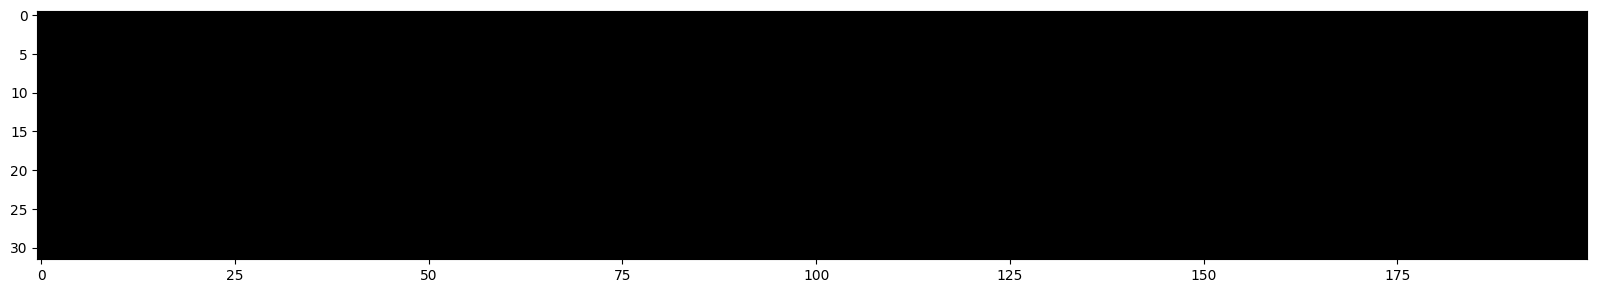

In [97]:
plt.figure(figsize=(20, 10))
plt.imshow(h.abs() > 0.99, cmap='gray', interpolation='nearest')

(array([597., 123.,  75.,  64.,  44.,  47.,  53.,  26.,  39.,  31.,  32.,
         33.,  24.,  26.,  39.,  53.,  62.,  50.,  65.,  56.,  95., 173.,
        238., 341., 770., 716., 373., 200., 175., 102.,  79.,  79.,  44.,
         51.,  28.,  55.,  21.,  24.,  30.,  25.,  43.,  64.,  29.,  40.,
         55.,  55.,  83.,  69., 112., 692.]),
 array([-1.  , -0.96, -0.92, -0.88, -0.84, -0.8 , -0.76, -0.72, -0.68,
        -0.64, -0.6 , -0.56, -0.52, -0.48, -0.44, -0.4 , -0.36, -0.32,
        -0.28, -0.24, -0.2 , -0.16, -0.12, -0.08, -0.04,  0.  ,  0.04,
         0.08,  0.12,  0.16,  0.2 ,  0.24,  0.28,  0.32,  0.36,  0.4 ,
         0.44,  0.48,  0.52,  0.56,  0.6 ,  0.64,  0.68,  0.72,  0.76,
         0.8 ,  0.84,  0.88,  0.92,  0.96,  1.  ]),
 <BarContainer object of 50 artists>)

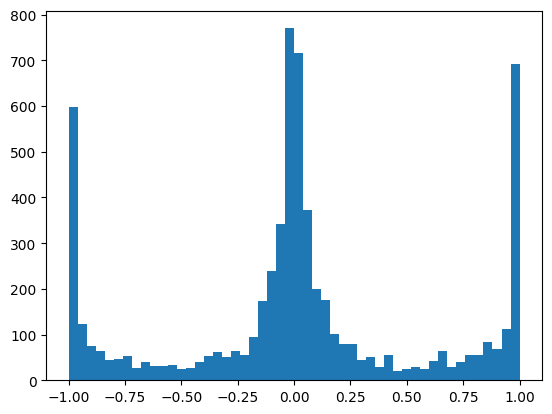

In [100]:
# iniital values of activation of hidden states (h)
h
plt.hist(h.view(-1).tolist(), 50)
# a lot of em are 1, -1. Tanh is a squashing function, compressing values into [0, 1]
# this has an effect of grad of tanh during backpropagate comes very close to 0

# you can change the input values but minimal change in output of tanh, in the flat region
# tanh is inactive, back gradient just get destroyed.
# sometimes we have dead neuron, no example would activate it. no learning.

(array([  1.,   0.,   0.,   3.,   3.,   3.,   4.,   6.,  11.,   9.,  18.,
         16.,  31.,  38.,  41.,  60.,  86., 120., 158., 160., 222., 231.,
        279., 367., 463., 711., 904., 400., 327., 320., 275., 250., 213.,
        188., 115.,  87.,  70.,  55.,  35.,  30.,  32.,  19.,  16.,   4.,
          4.,   4.,   6.,   4.,   0.,   1.]),
 array([-9.74665928, -9.37279343, -8.99892757, -8.62506172, -8.25119587,
        -7.87733002, -7.50346416, -7.12959831, -6.75573246, -6.38186661,
        -6.00800076, -5.6341349 , -5.26026905, -4.8864032 , -4.51253735,
        -4.13867149, -3.76480564, -3.39093979, -3.01707394, -2.64320808,
        -2.26934223, -1.89547638, -1.52161053, -1.14774467, -0.77387882,
        -0.40001297, -0.02614712,  0.34771873,  0.72158459,  1.09545044,
         1.46931629,  1.84318214,  2.217048  ,  2.59091385,  2.9647797 ,
         3.33864555,  3.71251141,  4.08637726,  4.46024311,  4.83410896,
         5.20797482,  5.58184067,  5.95570652,  6.32957237,  6.70343822,
 

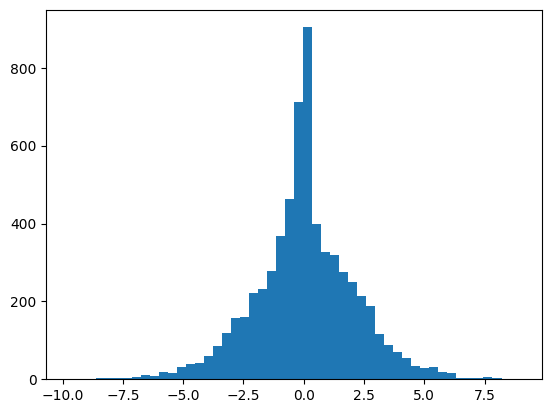

In [80]:
plt.hist(hpreact.view(-1).tolist(), 50)  # very broad values

In [81]:
# very high initialization loss, the probability distribution should be uniform (1/27), but isnt. Some characters have very high probability, some don't

In [ ]:
# 4D example of the issue
# logits = torch.tensor([0.0, 0.0, 0.0, 0.0])
logits = torch.randn(4) * 10  # need not be low, just equal would also be fine, because of normalization 
probs = torch.softmax(logits, dim=0)
loss = -probs[2].log()
logits, probs, loss

# when logits take extreme values then they have false over confidence

(tensor([-14.0727,   1.2267,   0.0745,  14.6759]),
 tensor([3.2705e-13, 1.4423e-06, 4.5569e-07, 1.0000e+00]),
 tensor(14.6015))

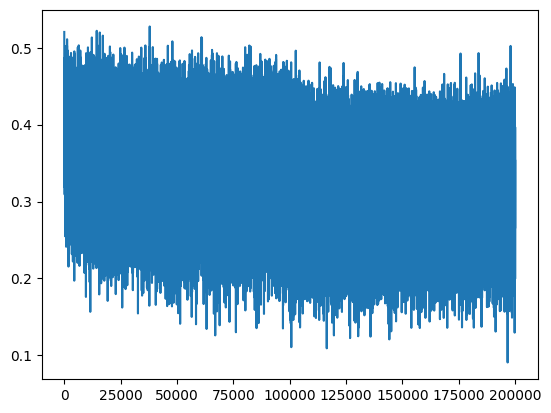

In [36]:
plt.plot(lossi)

In [120]:
@torch.no_grad()  # disabled gradient tracking for efficiency
def split_loss(split):
    x, y = {
        'train': (Xtr, Ytr),
        'val': (Xdev, Ydev),
        'test': (Xte, Yte),
    } [split]
    emb = C[x] # (N, block_size, n_embd)
    embcat = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embed)
    hpreact = embcat @ W1 + b1
    hpreact = bngain * (hpreact - hpreact.mean(0, keepdim=True)) / hpreact.std(0, keepdim=True) + bnbias
    h = torch.tanh(embcat @ W1 + b1)    # (N, n_hidden)
    logits = h @ W2 + b2                # (N, vocab_size)
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())

split_loss('train')
split_loss('val')

train 3.0179126262664795
val 3.061859369277954


In [ ]:
g = torch.Generator().manual_seed()
